Nilai Korelasi: -0.1872
Kekuatan Korelasi: Lemah Negatif


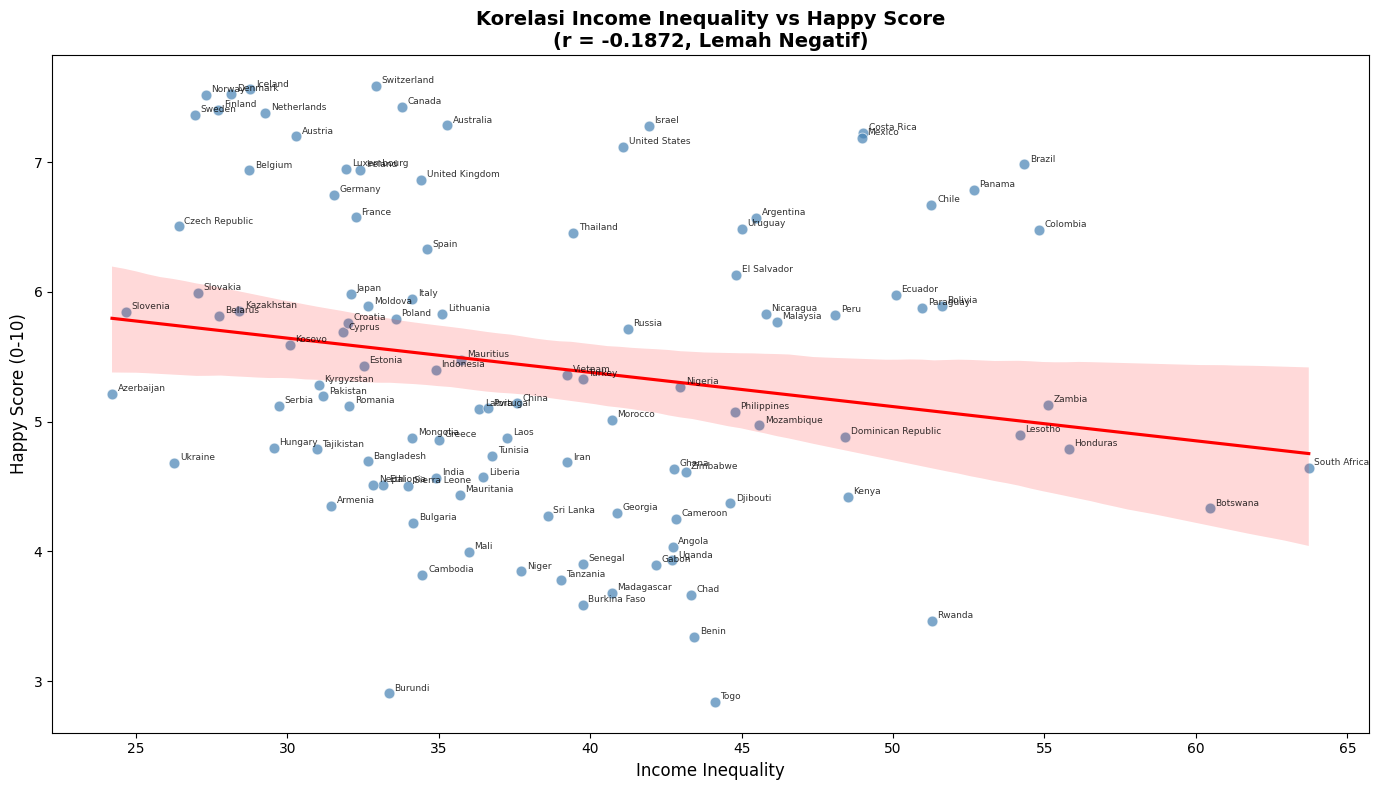

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset - Kelas D
df = pd.read_csv('/content/Kelas D_Happiness and Satisfaction.csv', sep=';', decimal=',')

# Hitung korelasi
korelasi = df['income_inequality'].corr(df['Happy Score (0-10)'])
print(f'Nilai Korelasi: {korelasi:.4f}')

if abs(korelasi) >= 0.7:
    kekuatan = 'Kuat'
elif abs(korelasi) >= 0.4:
    kekuatan = 'Sedang'
else:
    kekuatan = 'Lemah'

arah = 'Positif' if korelasi > 0 else 'Negatif'
print(f'Kekuatan Korelasi: {kekuatan} {arah}')

# Grafik 3 (Kategori C) - Scatter Plot + Label Negara
fig, ax = plt.subplots(figsize=(14, 8))

sns.scatterplot(
    data=df,
    x='income_inequality',
    y='Happy Score (0-10)',
    color='steelblue',
    alpha=0.7,
    s=60,
    ax=ax
)

# Garis tren
sns.regplot(
    data=df,
    x='income_inequality',
    y='Happy Score (0-10)',
    scatter=False,
    color='red',
    ax=ax
)

# Label nama negara tiap titik
for _, row in df.iterrows():
    ax.annotate(
        row['Country'],
        (row['income_inequality'], row['Happy Score (0-10)']),
        fontsize=6.5,
        alpha=0.8,
        xytext=(4, 2),
        textcoords='offset points'
    )

ax.set_title(f'Korelasi Income Inequality vs Happy Score\n(r = {korelasi:.4f}, {kekuatan} {arah})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Income Inequality', fontsize=12)
ax.set_ylabel('Happy Score (0-10)', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1246/781717226.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


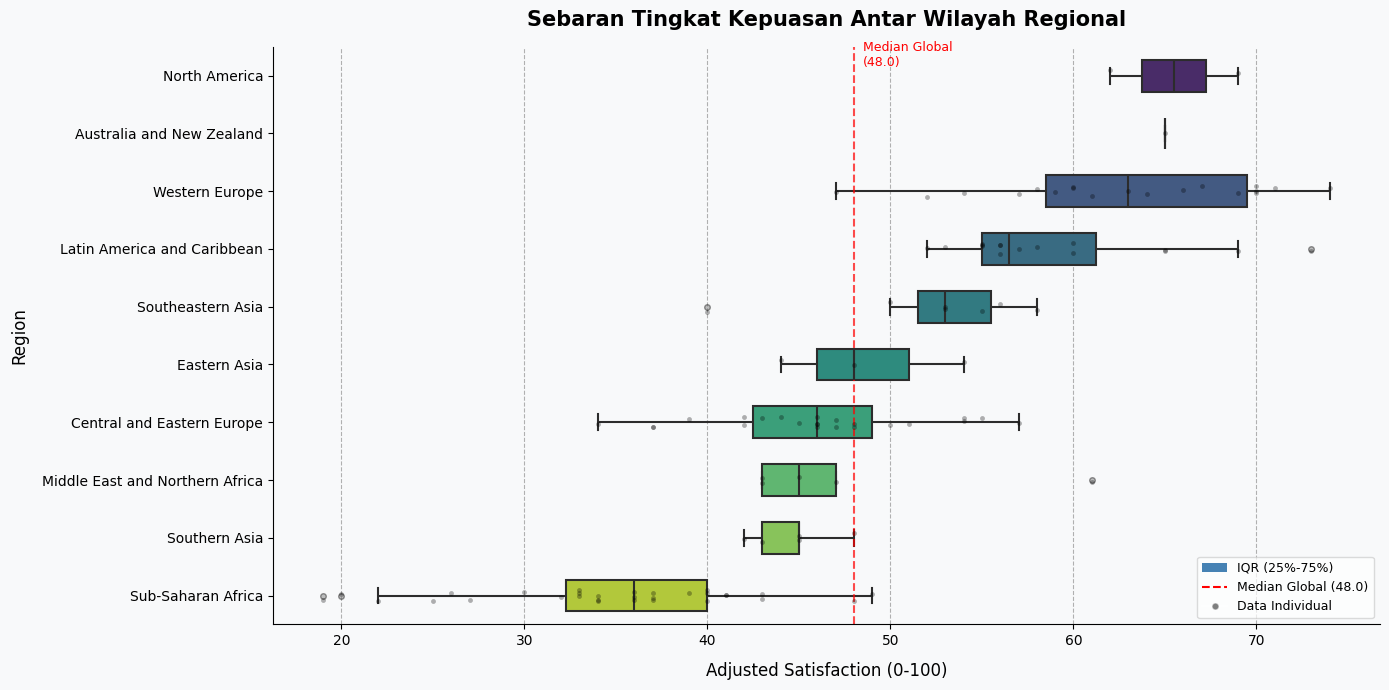

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Load dataset - Kelas D
df = pd.read_csv('/content/Kelas D_Happiness and Satisfaction.csv', sep=';', decimal=',')

# Bersihkan kolom Region
df['Region'] = df['Region'].str.strip().str.strip("'")

# Hitung median per region untuk sorting
median_order = (df.groupby('Region')['adjusted_satisfaction (0-100)']
                .median()
                .sort_values(ascending=False)
                .index.tolist())

# ── Grafik 4 (Kategori D) - Boxplot ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

# Boxplot utama
sns.boxplot(
    data=df,
    x='adjusted_satisfaction (0-100)',
    y='Region',
    order=median_order,
    palette='viridis',
    width=0.55,
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5),
    ax=ax
)

# Stripplot - titik data individual
sns.stripplot(
    data=df,
    x='adjusted_satisfaction (0-100)',
    y='Region',
    order=median_order,
    color='black',
    alpha=0.3,
    size=3.5,
    jitter=True,
    ax=ax
)

# Garis vertikal median global
global_median = df['adjusted_satisfaction (0-100)'].median()
ax.axvline(global_median, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(global_median + 0.5, -0.6, f'Median Global\n({global_median:.1f})',
        color='red', fontsize=9, va='top')

# Judul & label
ax.set_title('Sebaran Tingkat Kepuasan Antar Wilayah Regional',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Adjusted Satisfaction (0-100)', fontsize=12, labelpad=10)
ax.set_ylabel('Region', fontsize=12, labelpad=10)

# Grid & styling
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_elements = [
    mpatches.Patch(facecolor='steelblue', label='IQR (25%-75%)'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Median Global ({global_median:.1f})'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black',
               markersize=5, alpha=0.5, label='Data Individual')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.show()

     Country      GDP
0      Chile  1.10715
1     Panama  1.06353
2    Uruguay  1.06166
3  Argentina  1.05351
4     Mexico  1.02054


/tmp/ipykernel_1246/1270493892.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


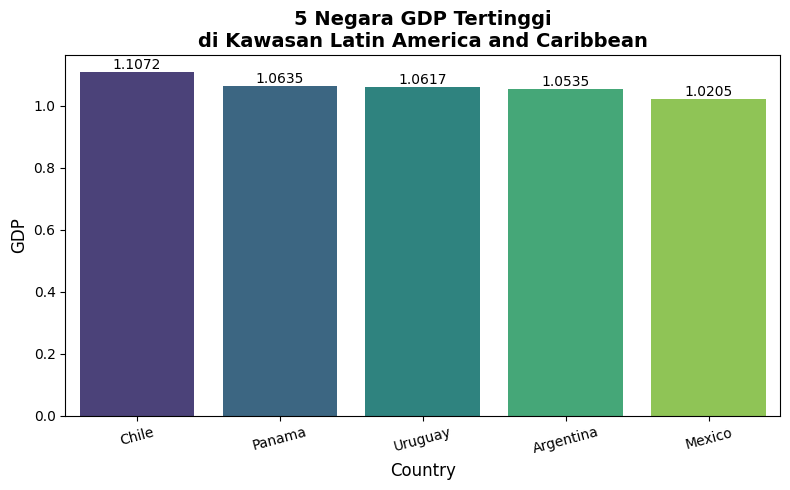

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset - Kelas D
df = pd.read_csv('/content/Kelas D_Happiness and Satisfaction.csv', sep=';', decimal=',')

# Bersihkan spasi/kutip di kolom Region
df['Region'] = df['Region'].str.strip().str.strip("'")

# Filter kawasan Latin America and Caribbean
lac = df[df['Region'] == 'Latin America and Caribbean']

# Ambil 5 negara GDP tertinggi
top5 = lac.nlargest(5, 'GDP')[['Country', 'GDP']].reset_index(drop=True)

print(top5)

# Grafik 1 (Kategori A) - Bar Chart
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=top5,
    x='Country',
    y='GDP',
    palette='viridis',
    ax=ax
)

ax.set_title('5 Negara GDP Tertinggi\ndi Kawasan Latin America and Caribbean',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('GDP', fontsize=12)
ax.tick_params(axis='x', rotation=15)

# Label nilai di atas setiap bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.4f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

                            Region  Median_Income_Inequality
1       Central and Eastern Europe                 31.035556
9                   Western Europe                 31.840000
7                    Southern Asia                 32.840000
2                     Eastern Asia                 34.132500
0        Australia and New Zealand                 35.285000
5                    North America                 37.440000
6                Southeastern Asia                 39.242500
4  Middle East and Northern Africa                 39.763333
8               Sub-Saharan Africa                 42.745000
3      Latin America and Caribbean                 49.557222


/tmp/ipykernel_1246/1802435316.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


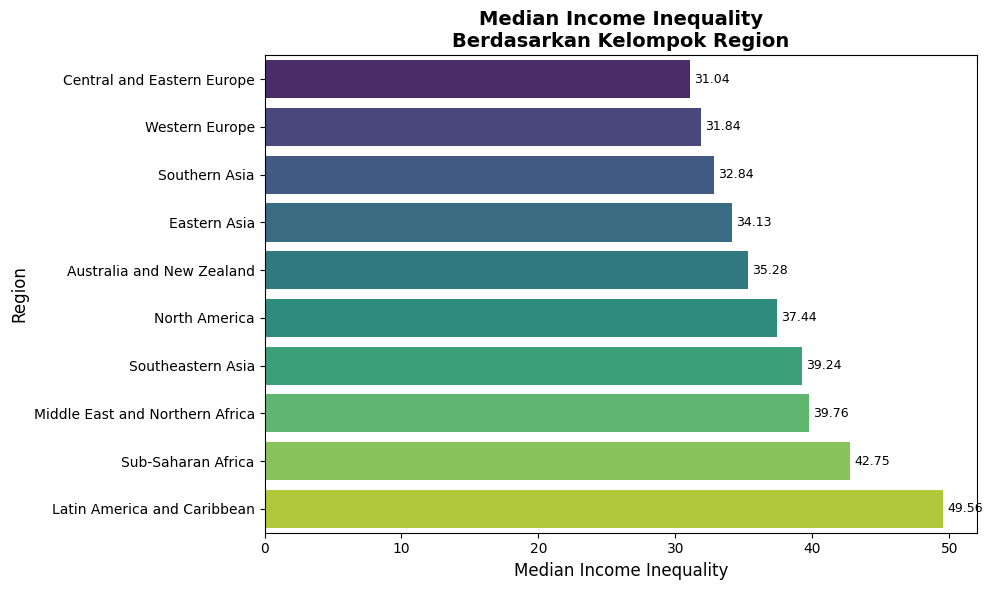

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset - Kelas D
df = pd.read_csv('/content/Kelas D_Happiness and Satisfaction.csv', sep=';', decimal=',')

# Bersihkan spasi/kutip di kolom Region jika ada
df['Region'] = df['Region'].str.strip().str.strip("'")

# Hitung median income_inequality berdasarkan Region
median_ineq = df.groupby('Region')['income_inequality'].median().reset_index()
median_ineq.columns = ['Region', 'Median_Income_Inequality']
median_ineq = median_ineq.sort_values('Median_Income_Inequality', ascending=True)

print(median_ineq)

# Grafik 1 (Kategori A) - Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=median_ineq,
    x='Median_Income_Inequality',
    y='Region',
    palette='viridis',
    ax=ax
)

ax.set_title('Median Income Inequality\nBerdasarkan Kelompok Region',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Median Income Inequality', fontsize=12)
ax.set_ylabel('Region', fontsize=12)

# Label nilai di ujung setiap bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.2f}',
        (p.get_width(), p.get_y() + p.get_height() / 2.),
        ha='left', va='center', fontsize=9, xytext=(3, 0),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()